In [11]:
# Importing necessary packages
import matplotlib.pyplot as plt
from scipy import ndimage
import numpy as np

from skimage import io, measure, draw
from skimage.util import crop
from skimage.filters import threshold_otsu
from skimage.morphology import area_closing, area_opening
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

filepath = '/Users/simenkrogstie/Documents/Programming/Høst 2024/INF250/Mandatory Exercise 2/DATA.JPG'

Threshold value: 0.40806062729779413


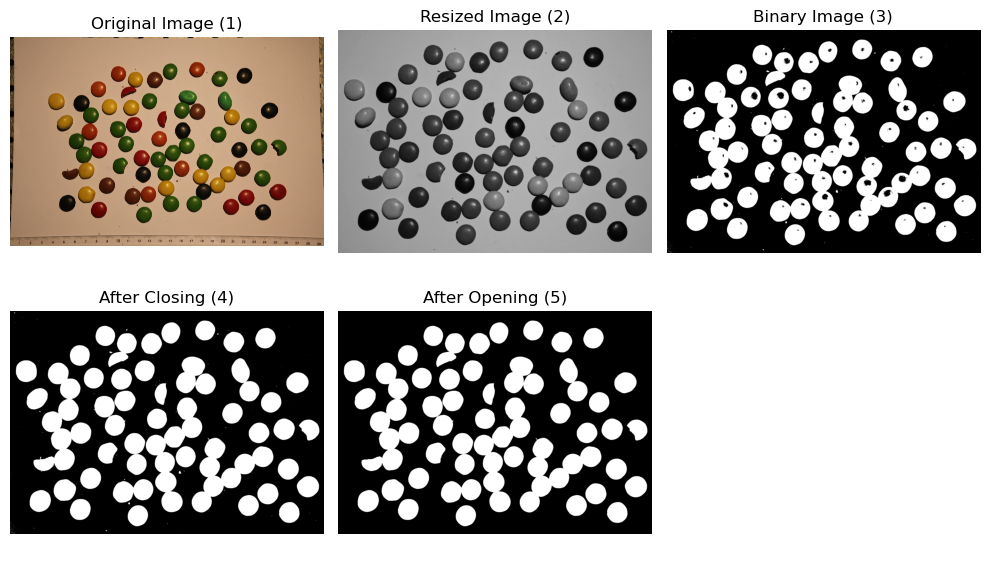

In [12]:
# Loading the image as grayscale 
img = io.imread(filepath, as_gray = True)

# Cropping the image 
crop_margins = ((300, 300), (600, 600))
resized_image = crop(img, crop_margins)

# Computing a Otsu threshold value
threshold_value = threshold_otsu(resized_image)
print(f"Threshold value: {threshold_value}")

# Manually selecting a threshold value and creating a binary version of the image
thres = 0.54
binary_img = resized_image < thres

# Closing operation to fill black holes in the foreground/choclates.
img_ac = area_closing(binary_img, area_threshold=10000)

# Opening operation to remove white spots in the background
img_ao = area_opening(img_ac, area_threshold=1000)


# Creating a figure for plotting different versions of the image
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

# Displaying the original image
axes[0, 0].imshow(io.imread(filepath), cmap='gray')     
axes[0, 0].set_title('Original Image (1)')
axes[0, 0].axis('off')

# Displaying the original resized image
axes[0, 1].imshow(resized_image, cmap='gray')           
axes[0, 1].set_title('Resized Image (2)')
axes[0, 1].axis('off')

# Displaying the binary image
axes[0, 2].imshow(binary_img, cmap='gray')              
axes[0, 2].set_title('Binary Image (3)')
axes[0, 2].axis('off')

# Displaying the image after closing
axes[1, 0].imshow(img_ac, cmap='gray')                  
axes[1, 0].set_title('After Closing (4)')
axes[1, 0].axis('off')

# Displaying the image after opening
axes[1, 1].imshow(img_ao, cmap='gray')                  
axes[1, 1].set_title('After Opening (5)')
axes[1, 1].axis('off')

# Removing unused slot in the figure
axes[1, 2].axis('off')                                

plt.tight_layout()
plt.show()

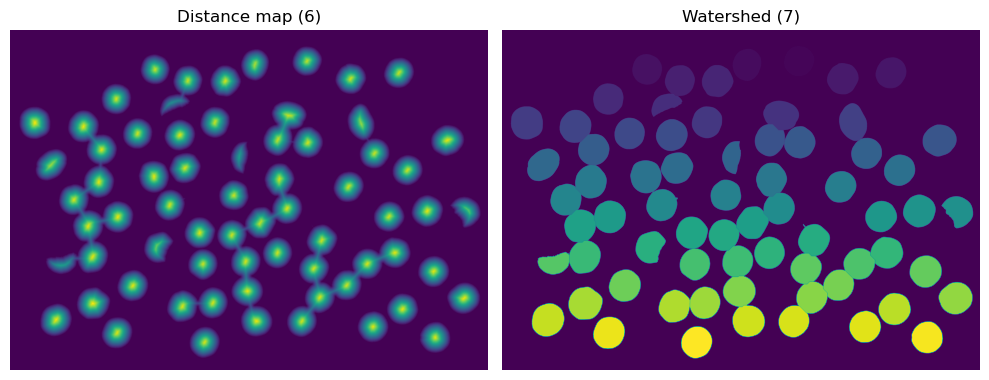

In [13]:
# Compute the euclidean distance transform of the binary image
distance = ndimage.distance_transform_edt(img_ao)

# Identify local maxima in the distance map
local_maxi_coords = peak_local_max(
                distance,                                                
                footprint = np.ones((30, 30)),     
                labels = img_ao,                  
                min_distance = 150           
                )

# Create a binary array to mark the local maxima positions
local_maxi = np.zeros_like(distance, dtype=bool)       
local_maxi[tuple(local_maxi_coords.T)] = True  

# Label the connected components in the local maxima array to use as markers
# for the watershed algorithm
markers = ndimage.label(local_maxi)[0]               

# Apply watershed algortihm to segment the image
labels = watershed(-distance, markers, mask=img_ao, watershed_line=True)

# Creating figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 10))

# Display the distance map on the first subplot
axes[0].imshow(distance)
axes[0].set_title('Distance map (6)')
axes[0].axis('off')

# Display the segmented image in the second subplot
axes[1].imshow(labels)
axes[1].set_title('Watershed (7)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

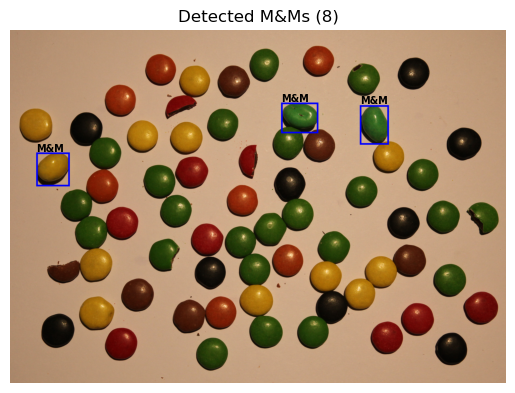

In [14]:
# Measure properties of labeled regions in 'labels'
properties = measure.regionprops(labels)

# Extract major axis lengths of each region.
major_axis_lengths = [prop.major_axis_length for prop in properties]
MnM_threshold = np.percentile(major_axis_lengths, 96)

# Load the original image and crop to same dims as the one that has been analyzed.
img_ = io.imread(filepath)
cropped_img_ = crop(img_, ((300, 300), (600, 600), (0, 0)), copy=True)

# Iterate over each regions that are in the top of major axis lengths.
for i, prop in enumerate(properties):
    if prop.major_axis_length > MnM_threshold:  
        y0, x0, y1, x1 = prop.bbox
        # Drawing a box around each object that is an M&M
        for offset in range(0, 15):
            rr, cc = draw.rectangle_perimeter(
                (y0 + offset, x0 + offset),
                end=(y1 - offset, x1 - offset),
                shape=cropped_img_.shape
            )
            cropped_img_[rr, cc] = (0, 0, 255)
        # Writes "M&M" on top of the boxes that are drawn around the detected objects.
        plt.text(x0, y0, "M&M", color='black', fontsize=7, fontweight='bold', 
                 bbox=dict(facecolor='white', alpha=0, edgecolor='none'),
                 verticalalignment='bottom')

# Displays the result of the analysis
plt.imshow(cropped_img_)
plt.title('Detected M&Ms (8)')
plt.axis('off')
plt.show()